<a href="https://colab.research.google.com/github/CyberSnorlax/ETF-Markowitz-Portfolio-Optimization/blob/Alpha2/Alpha2_ROE_DE_ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Connecting to folder through Google Drive
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/"Ensemble-Method"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Ensemble-Method


Part 1: Data Collection and Feature Engineering


In [9]:
#%% [code]
import yfinance as yf
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import joblib
import datetime

# File paths and date ranges
price_data_path = 'price_data.csv'
features_path = 'features_data.csv'
scaler_path = 'scaler.joblib'
sp500_index_path = 'sp500_index.csv'
# For saving scaled datasets (if needed)
X_train_scaled_path = 'X_train_scaled.joblib'
X_val_scaled_path   = 'X_val_scaled.joblib'
X_test_scaled_path  = 'X_test_scaled.joblib'
y_train_path = 'y_train.joblib'
y_val_path   = 'y_val.joblib'
y_test_path  = 'y_test.joblib'

# Define the periods for ML training
train_start = '2018-01-01'
train_end = '2021-12-31'
val_start = '2021-12-31'
val_end = '2022-12-31'
test_start = '2022-12-31'
test_end = '2023-12-31'
data_start = '2017-01-01'

# Function to fetch the list of S&P500 tickers from Wikipedia
def fetch_sp500_tickers():
    print("Fetching S&P500 tickers...")
    tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]['Symbol'].tolist()
    # Adjust ticker symbols if needed (e.g. BRK.B -> BRK-B)
    tickers = [t.replace('BRK.B', 'BRK-B').replace('BF.B', 'BF-B') for t in tickers]
    return tickers

# Function to fetch historical price data for all tickers
def fetch_price_data(tickers):
    if os.path.exists(price_data_path):
        print("Loading existing price data...")
        return pd.read_csv(price_data_path, index_col='Date', parse_dates=True)

    print("Downloading price data from yfinance...")
    data = yf.download(tickers, start=data_start, end=test_end, auto_adjust=True, threads=True)['Close']
    # Drop tickers with too many missing values
    data = data.dropna(axis=1, thresh=int(0.9 * len(data)))
    data.to_csv(price_data_path)
    print(f"Saved price data for {len(data.columns)} tickers to {price_data_path}")
    return data

# Function to fetch the S&P500 index (for regime detection or benchmark)
def fetch_sp500_index():
    if os.path.exists(sp500_index_path):
        print("Loading existing S&P500 index data...")
        return pd.read_csv(sp500_index_path, index_col='Date', parse_dates=True)

    print("Downloading S&P500 index data from yfinance...")
    sp500 = yf.download('^GSPC', start=data_start, end=test_end, auto_adjust=True)['Close']
    sp500.to_csv(sp500_index_path)
    print(f"Saved S&P500 index data to {sp500_index_path}")
    return sp500

# Function to retrieve fundamental data (ROE and Debt/Equity) for a ticker
def get_fundamentals(ticker):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        # ROE is often reported as a decimal (e.g., 0.20 for 20%)
        roe = info.get('returnOnEquity', None)
        # Debt-to-equity might be provided as a string or float (assume float)
        debt_to_equity = info.get('debtToEquity', None)
        return roe, debt_to_equity
    except Exception as e:
        print(f"Error fetching fundamentals for {ticker}: {e}")
        return None, None

# Function to calculate technical indicators (here we add a 200-day SMA)
def calculate_indicators(close):
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    sma200 = close.rolling(200).mean()
    sma_ratio = sma20 / sma50 - 1
    # Additional indicators
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    macd_hist = macd - signal
    volatility = close.pct_change().rolling(30).std() * np.sqrt(252)
    std20 = close.rolling(20).std()
    bb_width = (sma20 + 2 * std20 - (sma20 - 2 * std20)) / sma20

    df = pd.DataFrame({
        'sma_ratio': sma_ratio,
        'rsi': rsi,
        'macd_hist': macd_hist,
        'volatility': volatility,
        'bb_width': bb_width,
        'sma200': sma200
    })
    return df

# Function to calculate ARIMA-based features for stock data
def calculate_arima_features(close, periods=[5, 10, 21]):
    """
    Generate ARIMA-based prediction features for a stock's close price

    Parameters:
    close (pd.Series): Time series of close prices
    periods (list): List of forward-looking periods to forecast

    Returns:
    pd.DataFrame: DataFrame containing ARIMA prediction features
    """
    import warnings
    warnings.filterwarnings("ignore")

    # Container for ARIMA features
    arima_features = pd.DataFrame(index=close.index)

    # Prepare log returns for better ARIMA performance
    log_close = np.log(close)
    log_returns = log_close.diff().dropna()

    try:
        # Fit ARIMA model on log returns
        # Using simple ARIMA(1,0,1) for speed and stability
        model = ARIMA(log_returns, order=(1, 0, 1))
        model_fit = model.fit()

        # Generate forecasts for different periods
        for period in periods:
            forecast = model_fit.forecast(steps=period)

            # Calculate cumulative expected return over the forecast period
            cumulative_forecast = forecast.sum()

            # Convert back to price prediction (exp since we used log returns)
            current_log_price = log_close.iloc[-1]
            predicted_log_price = current_log_price + cumulative_forecast
            predicted_price = np.exp(predicted_log_price)

            # Calculate predicted return
            current_price = close.iloc[-1]
            predicted_return = (predicted_price / current_price) - 1

            # Add as feature
            arima_features[f'arima_pred_{period}d'] = np.nan
            arima_features.iloc[-1, arima_features.columns.get_loc(f'arima_pred_{period}d')] = predicted_return

            # Fill backward with rolling method to avoid lookahead bias
            arima_features[f'arima_pred_{period}d'] = arima_features[f'arima_pred_{period}d'].fillna(method='bfill')

        # Add ARIMA model parameters as features
        params = model_fit.params
        arima_features['arima_ar1'] = params.get('ar.L1', 0)
        arima_features['arima_ma1'] = params.get('ma.L1', 0)
        arima_features['arima_const'] = params.get('const', 0)

        # Add model quality metrics
        arima_features['arima_aic'] = model_fit.aic
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252)  # Annualized

    except Exception as e:
        # Handle errors gracefully
        print(f"ARIMA model error: {e}")
        # Fill with zeros if model fails
        for period in periods:
            arima_features[f'arima_pred_{period}d'] = 0
        arima_features['arima_ar1'] = 0
        arima_features['arima_ma1'] = 0
        arima_features['arima_const'] = 0
        arima_features['arima_aic'] = 0
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252) if not log_returns.empty else 0

    return arima_features

# Main function to prepare the feature dataset for ML training
def prepare_data(price_data, sp500_index, tickers):
    features_list = []

    # For regime or market state (optional)
    regime = (sp500_index.rolling(200).mean() > sp500_index).astype(int)  # 1 = bear, 0 = bull

    for ticker in tickers:
        print(f"Processing {ticker} ...")
        try:
            close = price_data[ticker].dropna()
            if len(close) < 252:
                print(f"Skipping {ticker}: insufficient data")
                continue

            # Compute technical indicators
            tech_df = calculate_indicators(close)

            # Compute ARIMA features
            arima_df = calculate_arima_features(close, periods=[5, 10, 21])

            # Merge technical and ARIMA features
            features_df = pd.concat([tech_df, arima_df], axis=1)
            # Remove duplicate columns if any
            features_df = features_df.loc[:,~features_df.columns.duplicated()]

            # Get fundamental data
            roe, debt_to_equity = get_fundamentals(ticker)
            if roe is None or debt_to_equity is None:
                print(f"Skipping {ticker}: missing fundamental data")
                continue

            # For demonstration, assume roe is in decimal form (e.g., 0.25 for 25%) and debt_to_equity as float
            features_df['roe'] = roe
            features_df['debt_to_equity'] = debt_to_equity

            # Compute a binary flag: is price above 200-day SMA?
            features_df['above_sma200'] = (close > features_df['sma200']).astype(int)

            # Fundamental Filters as additional features (you can also use these to filter later)
            # For long candidates: price > sma200, roe > 0.20, debt_to_equity < 1.
            features_df['fund_long'] = ((close > features_df['sma200']) & (roe > 0.20) & (debt_to_equity < 1)).astype(int)
            # For short candidates: price < sma200, roe < 0.10, debt_to_equity > 2.
            features_df['fund_short'] = ((close < features_df['sma200']) & (roe < 0.10) & (debt_to_equity > 2)).astype(int)

            # Add ticker and date information
            features_df['ticker'] = ticker
            features_df['date'] = close.index

            # Calculate forward return (using 21 trading days ~ 1 month)
            features_df['future_price'] = close.shift(-21)
            features_df['fwd_return'] = (features_df['future_price'] / close) - 1

            # Drop rows with missing forward return (and ensure indicator columns are not NA)
            feature_cols = list(features_df.columns.difference(['ticker', 'date', 'future_price', 'fwd_return']))
            features_df = features_df.dropna(subset=['fwd_return'] + feature_cols)
            if len(features_df) < 50:
                print(f"Skipping {ticker}: insufficient rows after cleaning")
                continue

            # Create labels based on forward return quantiles
            # Here we use three classes: -1 (poor return), 0 (neutral), 1 (good return)
            features_df['label'] = pd.qcut(features_df['fwd_return'], q=[0, 0.25, 0.75, 1],
                                       labels=[-1, 0, 1], duplicates='drop').astype(int)

            # Include a market regime feature (align using ffill)
            features_df['regime'] = regime.reindex(features_df.index, method='ffill').fillna(0)

            features_list.append(features_df)
        except Exception as e:
            print(f"Error processing {ticker}: {e}")

    if not features_list:
        raise ValueError("No valid feature data was generated.")

    all_features = pd.concat(features_list, ignore_index=True)
    all_features.to_csv(features_path, index=False)
    print(f"Saved features data to {features_path}")
    print(f"Processed a total of {len(features_list)} stocks with {len(all_features)} data points and {len(all_features.columns) - 4} features")

    return all_features

# --- Main execution for Part 1 ---
tickers = fetch_sp500_tickers()
price_data = fetch_price_data(tickers)
sp500_index = fetch_sp500_index()
features_df = prepare_data(price_data, sp500_index, tickers)

Fetching S&P500 tickers...
Loading existing price data...
Loading existing S&P500 index data...
Processing MMM ...
Processing AOS ...
Processing ABT ...
Skipping ABT: missing fundamental data
Processing ABBV ...
Processing ACN ...
Processing ADBE ...
Processing AMD ...
Processing AES ...
Processing AFL ...
Processing A ...
Processing APD ...
Processing ABNB ...
Error processing ABNB: 'ABNB'
Processing AKAM ...
Processing ALB ...
Processing ARE ...
Processing ALGN ...
Processing ALLE ...
Processing LNT ...
Processing ALL ...
Processing GOOGL ...
Processing GOOG ...
Processing MO ...
Skipping MO: missing fundamental data
Processing AMZN ...
Processing AMCR ...
Processing AEE ...
Processing AEP ...
Processing AXP ...
Processing AIG ...
Processing AMT ...
Processing AWK ...
Processing AMP ...
Processing AME ...
Processing AMGN ...
Processing APH ...
Processing ADI ...
Processing ANSS ...
Processing AON ...
Processing APA ...
Processing APO ...
Processing AAPL ...
Processing AMAT ...
Proces

Part 2: Model Training and Prediction Aggregation

In [10]:
#%% [code]
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def train_models(features_df):
    # Define feature columns (updated to include ARIMA features)
    base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'roe', 'debt_to_equity',
                'above_sma200', 'fund_long', 'fund_short', 'regime']

    # Find ARIMA feature columns (any column starting with 'arima_')
    arima_cols = [col for col in features_df.columns if col.startswith('arima_')]

    # Combine base features with ARIMA features
    X_cols = base_cols + arima_cols

    print(f"Training models with {len(X_cols)} features, including {len(arima_cols)} ARIMA features")
    print("ARIMA features:", arima_cols)

    # Convert date column to datetime
    features_df['date'] = pd.to_datetime(features_df['date'])

    # Split the data into Train, Validation, and Test sets based on date
    train_df = features_df[(features_df['date'] >= train_start) & (features_df['date'] <= train_end)]
    val_df   = features_df[(features_df['date'] > train_end) & (features_df['date'] <= val_end)]
    test_df  = features_df[(features_df['date'] > val_end) & (features_df['date'] <= test_end)]

    X_train, y_train = train_df[X_cols], train_df['label']
    X_val, y_val     = val_df[X_cols], val_df['label']
    X_test, y_test   = test_df[X_cols], test_df['label']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    joblib.dump(scaler, scaler_path)
    joblib.dump(X_train_scaled, X_train_scaled_path)
    joblib.dump(X_val_scaled, X_val_scaled_path)
    joblib.dump(X_test_scaled, X_test_scaled_path)
    joblib.dump(y_train, y_train_path)
    joblib.dump(y_val, y_val_path)
    joblib.dump(y_test, y_test_path)
    print("Saved scaled data and labels.")

    # Train Logistic Regression
    lr = LogisticRegression(multi_class='multinomial', random_state=42, max_iter=1000)  # Increased max_iter for convergence
    lr.fit(X_train_scaled, y_train)
    lr_val_acc = accuracy_score(y_val, lr.predict(X_val_scaled))
    print(f"Logistic Regression Validation Accuracy: {lr_val_acc:.4f}")
    joblib.dump(lr, 'lr_model.joblib')

    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    knn_val_acc = accuracy_score(y_val, knn.predict(X_val_scaled))
    print(f"KNN Validation Accuracy: {knn_val_acc:.4f}")
    joblib.dump(knn, 'knn_model.joblib')

    # Prepare sequences for LSTM
    sequence_length = 20
    def create_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i+seq_len)])
            ys.append(y.iloc[i+seq_len])
        return np.array(Xs), np.array(ys)

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, sequence_length)
    X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val, sequence_length)
    X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test, sequence_length)

    # One-hot encode the labels for LSTM (3 classes: -1, 0, 1)
    y_train_seq = pd.get_dummies(y_train_seq).values
    y_val_seq   = pd.get_dummies(y_val_seq).values
    y_test_seq  = pd.get_dummies(y_test_seq).values

    # Build LSTM model
    lstm = Sequential([
        LSTM(50, return_sequences=True, input_shape=(sequence_length, len(X_cols))),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    lstm.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_data=(X_val_seq, y_val_seq), verbose=1)
    lstm_val_acc = lstm.evaluate(X_val_seq, y_val_seq, verbose=0)[1]
    print(f"LSTM Validation Accuracy: {lstm_val_acc:.4f}")
    lstm.save('lstm_model.h5')

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

# --- Main execution for Part 2 ---
X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test = train_models(features_df)


Training models with 19 features, including 8 ARIMA features
ARIMA features: ['arima_pred_5d', 'arima_pred_10d', 'arima_pred_21d', 'arima_ar1', 'arima_ma1', 'arima_const', 'arima_aic', 'arima_volatility']
Saved scaled data and labels.
Logistic Regression Validation Accuracy: 0.3797
KNN Validation Accuracy: 0.3515
Epoch 1/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 195s 18ms/step - accuracy: 0.5351 - loss: 0.9891 - val_accuracy: 0.3918 - val_loss: 1.3887
Epoch 2/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 193s 18ms/step - accuracy: 0.5559 - loss: 0.9442 - val_accuracy: 0.3910 - val_loss: 1.4965
Epoch 3/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 197s 18ms/step - accuracy: 0.5673 - loss: 0.9191 - val_accuracy: 0.3872 - val_loss: 1.5514
Epoch 4/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 196s 18ms/step - accuracy: 0.5773 - loss: 0.8996 - val_accuracy: 0.3777 - val_loss: 1.6944
Epoch 5/10
10792/10792 ━━━━━━━━━━━━━━━━━━━━ 196s 18ms/step - accuracy: 0.5880 - loss: 0.8817 - val_accuracy: 0.3714 - val_loss: 1.7786
Epoch 6/10

LSTM Validation Accuracy: 0.3691


In [11]:
#%% [code]
def aggregate_predictions(features_df, scaler):
    # Get base columns
    base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'roe', 'debt_to_equity',
                'above_sma200', 'fund_long', 'fund_short', 'regime']

    # Find ARIMA feature columns (any column starting with 'arima_')
    arima_cols = [col for col in features_df.columns if col.startswith('arima_')]

    # Combine base features with ARIMA features
    X_cols = base_cols + arima_cols

    print(f"Making predictions with {len(X_cols)} features, including {len(arima_cols)} ARIMA features")

    X_full = features_df[X_cols]
    X_full_scaled = scaler.transform(X_full)

    # Load trained models
    lr = joblib.load('lr_model.joblib')
    knn = joblib.load('knn_model.joblib')
    lstm = load_model('lstm_model.h5')

    # Get predictions from LR and KNN
    lr_preds = lr.predict(X_full_scaled)
    knn_preds = knn.predict(X_full_scaled)

    # For LSTM, we need to create sequences; choose a sequence length (e.g., 10)
    seq_len = 10
    def create_sequences(X, seq_len):
        Xs = []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i+seq_len)])
        return np.array(Xs)
    X_full_seq = create_sequences(X_full_scaled, seq_len)
    lstm_preds_prob = lstm.predict(X_full_seq, verbose=0)
    lstm_preds = np.argmax(lstm_preds_prob, axis=1) - 1  # Convert from one-hot (0,1,2) to (-1,0,1)

    # Align predictions (discard the first 'seq_len' rows for LSTM)
    pred_df = features_df.iloc[seq_len:].copy()
    pred_df['lr_pred'] = lr_preds[seq_len:]
    pred_df['knn_pred'] = knn_preds[seq_len:]
    pred_df['lstm_pred'] = lstm_preds

    # Ensemble prediction: average the three predictions
    pred_df['ensemble_pred'] = pred_df[['lr_pred', 'knn_pred', 'lstm_pred']].mean(axis=1)

    # Add ARIMA predictions as a feature for interpretability
    for period in [5, 10, 21]:
        col = f'arima_pred_{period}d'
        if col in pred_df.columns:
            # Create a normalized prediction (-1 to 1 scale)
            pred_df[f'arima_{period}d_signal'] = np.where(
                pred_df[col] > 0.01, 1,  # Positive return > 1% → buy signal
                np.where(pred_df[col] < -0.01, -1, 0)  # Negative return < -1% → sell signal
            )

    # Save predictions
    pred_df.to_csv('model_predictions.csv', index=False)
    print("Saved model predictions to model_predictions.csv")
    return pred_df

# --- Aggregate predictions ---
scaler = joblib.load(scaler_path)
pred_df = aggregate_predictions(features_df, scaler)


Making predictions with 19 features, including 8 ARIMA features


Saved model predictions to model_predictions.csv


Part 3: Portfolio Construction and Backtesting


Constructing portfolio selections (Modified)...
Saved portfolio selections to portfolio_selections.csv
Backtesting portfolio (Modified)...

2023-01 Positions:
Long: ['ERIE']
Short: ['HRL', 'FIS', 'EQR']
2023-01 Monthly Return: -0.0531

2023-02 Positions:
Long: ['ANET', 'MPWR']
Short: ['AVB', 'RVTY', 'MDT', 'BALL']
2023-02 Monthly Return: 0.1604

2023-03 Positions:
Long: ['ANET', 'ERIE']
Short: ['INVH', 'IP', 'WELL', 'KMX']
2023-03 Monthly Return: 0.0959

2023-04 Positions:
Long: ['ANET', 'ERIE', 'MPWR']
Short: ['ETR', 'CRL', 'NWSA', 'NEE', 'TSN', 'CTRA']
2023-04 Monthly Return: -0.0677

2023-05 Positions:
Long: ['ANET', 'MPWR']
Short: ['KIM', 'CTRA', 'DLR', 'REG', 'EMR']
2023-05 Monthly Return: 0.1038

2023-06 Positions:
Long: ['MPWR', 'ANET']
Short: ['REG', 'OXY', 'KIM']
2023-06 Monthly Return: -0.0342

2023-07 Positions:
Long: ['MPWR', 'ANET']
Short: ['TSN', 'OXY', 'RVTY', 'IP']
2023-07 Monthly Return: -0.0870

2023-08 Positions:
Long: ['TPL', 'MPWR']
Short: ['ALB', 'KHC', 'MOS', 'VT

[*********************100%***********************]  1 of 1 completed


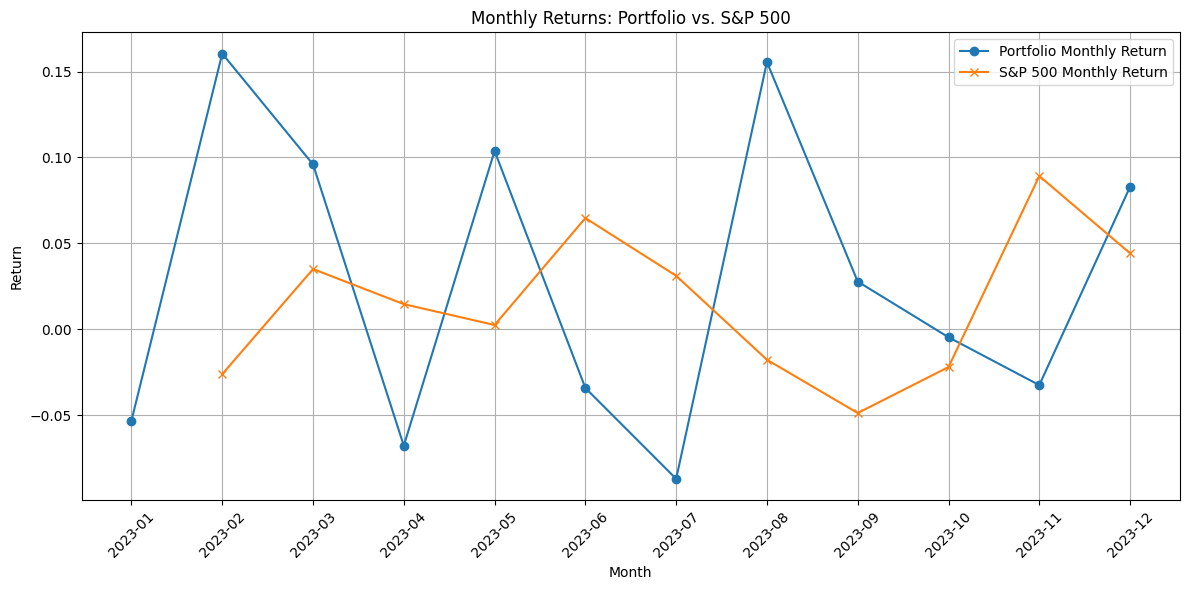

In [12]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Define the test period (adjust these if needed)
test_start = '2022-12-31'
test_end = '2023-12-31'

def construct_portfolio_modified(pred_df, n_long=10, n_short=10):
    """Construct monthly long-short portfolio based on ensemble predictions,
    print long and short positions for each month, and save the selections."""
    print("Constructing portfolio selections (Modified)...")
    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df['year_month'] = pred_df['date'].dt.to_period('M')

    portfolio_list = []
    for period, group in pred_df.groupby('year_month'):
        # Apply fundamental filters:
        # Long: price > 200-day SMA, roe > 20%, debt_to_equity < 1
        group_long = group[(group['above_sma200'] == 1) & (group['roe'] > 0.20) & (group['debt_to_equity'] < 1)]
        # Short: price < 200-day SMA, roe < 10%, debt_to_equity > 2
        group_short = group[(group['above_sma200'] == 0) & (group['roe'] < 0.10) & (group['debt_to_equity'] > 2)]

        group_long_sorted = group_long.sort_values('ensemble_pred', ascending=False)
        group_short_sorted = group_short.sort_values('ensemble_pred', ascending=True)

        if len(group_long_sorted) < n_long or len(group_short_sorted) < n_short:
            print(f"Period {period}: Not enough candidates for long or short positions. Skipping.")
            continue

        long_stocks = group_long_sorted.head(n_long)[['ticker', 'date', 'ensemble_pred']]
        long_stocks['position'] = 'long'
        short_stocks = group_short_sorted.head(n_short)[['ticker', 'date', 'ensemble_pred']]
        short_stocks['position'] = 'short'

        month_portfolio = pd.concat([long_stocks, short_stocks])
        month_portfolio['year_month'] = period
        portfolio_list.append(month_portfolio)

    if not portfolio_list:
        raise ValueError("No valid portfolio selections could be made.")

    portfolio_df = pd.concat(portfolio_list, ignore_index=True)
    portfolio_df.to_csv('portfolio_selections.csv', index=False)
    print("Saved portfolio selections to portfolio_selections.csv")

    return portfolio_df

def backtest_portfolio_modified(price_data, portfolio_df):
    """Backtest the portfolio, print monthly returns, and plot them against S&P 500."""
    print("Backtesting portfolio (Modified)...")
    # Get price data for the test period
    price_data_test = price_data.loc[test_start:test_end]

    portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
    portfolio_df = portfolio_df[(portfolio_df['date'] >= test_start) & (portfolio_df['date'] <= test_end)]
    portfolio_df['year_month'] = portfolio_df['date'].dt.to_period('M')

    daily_returns = price_data_test.pct_change().dropna()
    monthly_returns = []

    for period, group in portfolio_df.groupby('year_month'):
        month_start = group['date'].min()
        month_end = month_start + pd.offsets.MonthEnd(0)
        if month_end > pd.to_datetime(test_end):
            month_end = pd.to_datetime(test_end)

        month_ret = daily_returns.loc[month_start:month_end]
        if month_ret.empty:
            continue

        # Get unique long and short tickers for the month
        long_tickers = group[group['position'] == 'long']['ticker'].unique().tolist()
        short_tickers = group[group['position'] == 'short']['ticker'].unique().tolist()

        # Print positions for this month
        print(f"\n{period} Positions:")
        print("Long:", long_tickers)
        print("Short:", short_tickers)

        # Calculate average returns for long and short sides
        long_returns = month_ret[long_tickers].mean(axis=1) if long_tickers else pd.Series()
        short_returns = month_ret[short_tickers].mean(axis=1) if short_tickers else pd.Series()
        if long_returns.empty or short_returns.empty:
            print(f"Skipping {period}: insufficient returns data.")
            continue

        long_cum_return = (1 + long_returns).cumprod().iloc[-1] - 1
        short_cum_return = (1 + short_returns).cumprod().iloc[-1] - 1
        portfolio_return = (long_cum_return - short_cum_return)

        print(f"{period} Monthly Return: {portfolio_return:.4f}")
        monthly_returns.append({
            'year_month': str(period),
            'long_return': long_cum_return,
            'short_return': short_cum_return,
            'portfolio_return': portfolio_return
        })

    returns_df = pd.DataFrame(monthly_returns)
    returns_df.to_csv('portfolio_returns.csv', index=False)
    print("Saved portfolio returns to portfolio_returns.csv")

    # Fetch S&P 500 monthly returns for the same period
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    sp500_monthly = sp500.resample('M').last().pct_change().dropna()
    sp500_monthly.index = sp500_monthly.index.to_period('M')

    # Plot portfolio vs. S&P 500 monthly returns
    plt.figure(figsize=(12,6))
    plt.plot(returns_df['year_month'], returns_df['portfolio_return'], marker='o', label='Portfolio Monthly Return')
    plt.plot(sp500_monthly.index.astype(str), sp500_monthly.values, marker='x', label='S&P 500 Monthly Return')
    plt.title('Monthly Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return returns_df

# --- Usage in Step 3 ---
# Assume pred_df and price_data are available from previous steps.
portfolio_df_mod = construct_portfolio_modified(pred_df, n_long=10, n_short=10)
returns_df_mod = backtest_portfolio_modified(price_data, portfolio_df_mod)


Part 4: Performance Evaluation and Graphing

Evaluating portfolio performance...


[*********************100%***********************]  1 of 1 completed

Saved performance metrics to portfolio_performance.csv

Portfolio Performance Summary:
Total Return: 0.3533
Annualized Return: 0.3533
Annualized Volatility: 0.3040
Sharpe Ratio: 1.0964
Maximum Drawdown: -0.1182


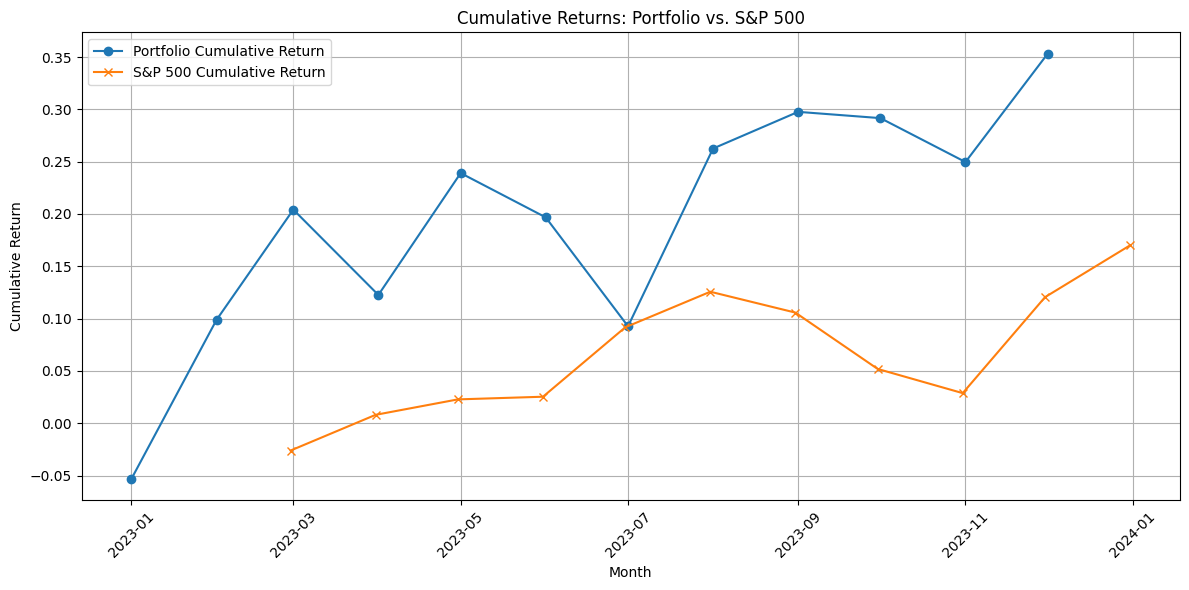

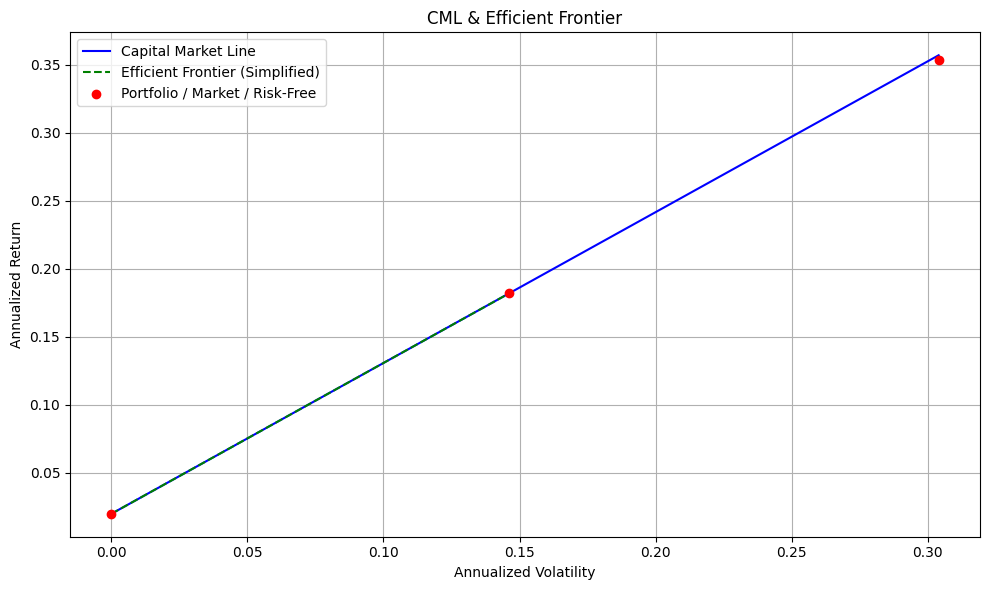

In [13]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

def evaluate_performance(returns_df, risk_free_rate=0.02):
    print("Evaluating portfolio performance...")
    returns_df['year_month'] = pd.to_datetime(returns_df['year_month'])
    returns_df = returns_df.sort_values('year_month')

    # Compute cumulative returns for portfolio
    returns_df['cumulative_return'] = (1 + returns_df['portfolio_return']).cumprod() - 1

    n_months = len(returns_df)
    total_return = returns_df['cumulative_return'].iloc[-1] if n_months > 0 else 0
    annualized_return = ((1 + total_return) ** (12 / n_months)) - 1 if n_months > 0 else 0
    monthly_vol = returns_df['portfolio_return'].std()
    annualized_vol = monthly_vol * np.sqrt(12) if monthly_vol is not None else 0
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol != 0 else 0

    # Maximum drawdown calculation
    cumulative = (1 + returns_df['portfolio_return']).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    performance_metrics = {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

    perf_df = pd.DataFrame([performance_metrics])
    perf_df.to_csv('portfolio_performance.csv', index=False)
    print("Saved performance metrics to portfolio_performance.csv")

    print("\nPortfolio Performance Summary:")
    for key, value in performance_metrics.items():
        print(f"{key}: {value:.4f}")

    # --- Modified S&P 500 cumulative returns calculation ---
    # Fetch S&P 500 data for the test period
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    # Get month-end close prices
    sp500_monthly_close = sp500.resample('ME').last()
    # Calculate month-over-month returns
    sp500_monthly_returns = sp500_monthly_close.pct_change().dropna()
    # Compute cumulative returns from these monthly returns
    sp500_monthly_cum = (1 + sp500_monthly_returns).cumprod() - 1

    # Plot cumulative returns vs. S&P 500
    plt.figure(figsize=(12,6))
    plt.plot(returns_df['year_month'], returns_df['cumulative_return'], marker='o', label='Portfolio Cumulative Return')
    plt.plot(sp500_monthly_cum.index, sp500_monthly_cum.values, marker='x', label='S&P 500 Cumulative Return')
    plt.title('Cumulative Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Cumulative Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Compute Capital Market Line (CML) and a simplified Efficient Frontier
    # Use the monthly returns from the S&P 500
    market_return = float(sp500_monthly_returns.mean() * 12)
    market_vol = float(sp500_monthly_returns.std() * np.sqrt(12))
    cml_slope = (market_return - risk_free_rate) / market_vol if market_vol != 0 else 0
    cml_vols = np.linspace(0, max(annualized_vol, market_vol), 100)
    cml_returns = risk_free_rate + cml_slope * cml_vols

    eff_vols = np.linspace(0, market_vol, 100)
    eff_returns = risk_free_rate + (market_return - risk_free_rate) * (eff_vols / market_vol)

    plt.figure(figsize=(10,6))
    plt.plot(cml_vols, cml_returns, label='Capital Market Line', color='blue')
    plt.plot(eff_vols, eff_returns, label='Efficient Frontier (Simplified)', color='green', linestyle='--')
    plt.scatter([annualized_vol, market_vol, 0], [annualized_return, market_return, risk_free_rate],
                color='red', zorder=5, label='Portfolio / Market / Risk-Free')
    plt.title('CML & Efficient Frontier')
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Return')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return returns_df, performance_metrics

# --- Usage in Step 4 ---
returns_df_final, performance_metrics_final = evaluate_performance(returns_df_mod)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Portfolio Performance Summary:
Total Return: 0.2473
Annualized Return: 0.2506
Annualized Volatility: 0.1311
Sharpe Ratio: 1.7591
Maximum Drawdown: -0.1233


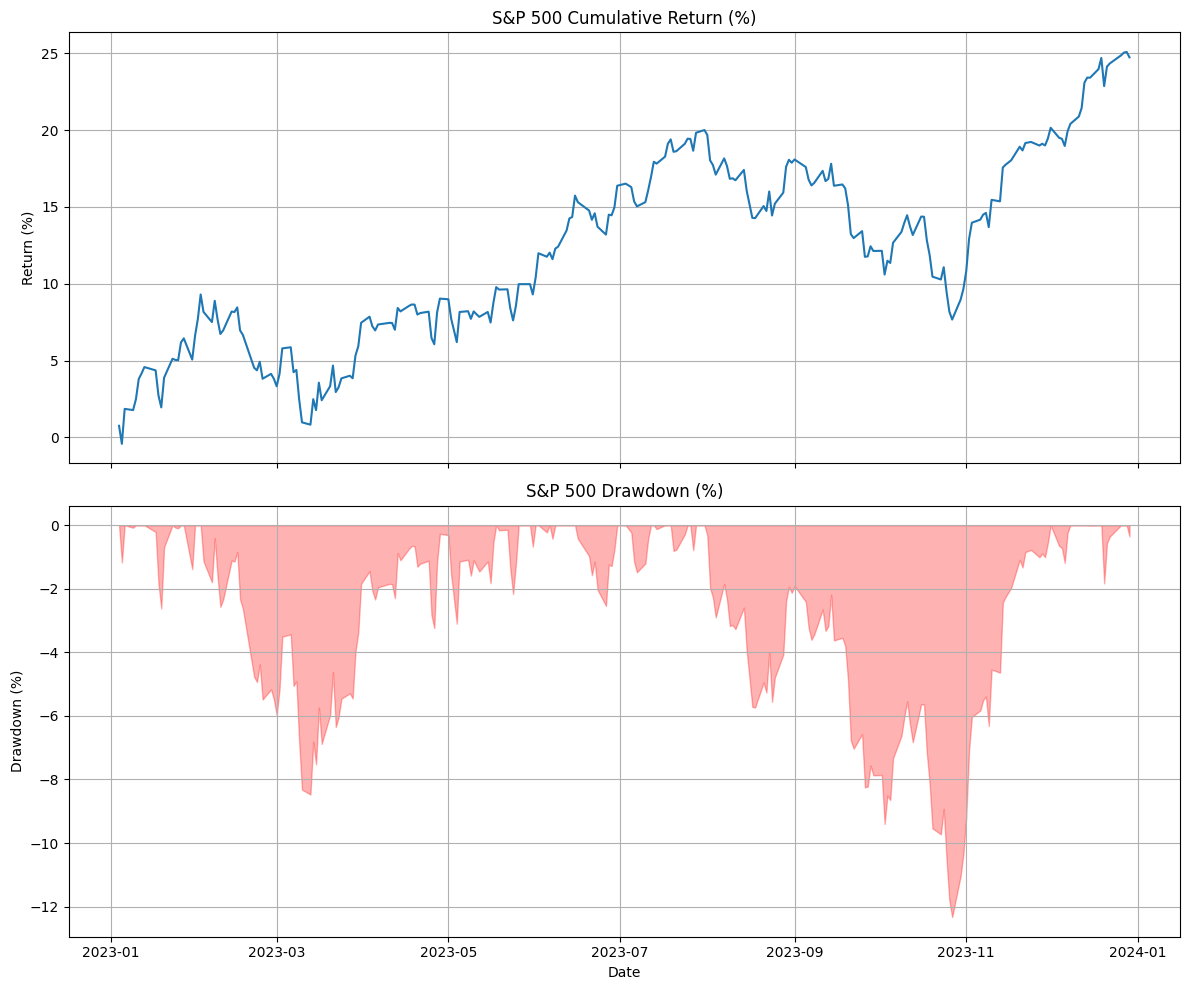

In [14]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

def get_portfolio_summary(start_date, end_date, ticker='^GSPC'):
    """
    Get S&P 500 portfolio summary for a specific time period

    Parameters:
    start_date (str): Start date in 'YYYY-MM-DD' format
    end_date (str): End date in 'YYYY-MM-DD' format
    ticker (str): Yahoo Finance ticker symbol, default is S&P 500

    Returns:
    dict: Portfolio performance metrics
    """
    # Download S&P 500 data
    sp500 = yf.download(ticker, start=start_date, end=end_date)

    # Check available columns and use Close if Adj Close is not available
    price_col = 'Close'  # Use Close instead of Adj Close

    # Calculate daily returns
    sp500['Daily Return'] = sp500[price_col].pct_change()

    # Drop NaN values
    sp500 = sp500.dropna()

    # Calculate metrics
    daily_returns = sp500['Daily Return']
    cumulative_return = (1 + daily_returns).prod() - 1
    trading_days = 252  # Standard assumption for trading days in a year

    # Annualized return
    total_days = len(sp500)
    years = total_days / trading_days
    annualized_return = (1 + cumulative_return) ** (1 / years) - 1

    # Annualized volatility
    annualized_volatility = daily_returns.std() * np.sqrt(trading_days)

    # Sharpe ratio (assuming risk-free rate of 0.02)
    risk_free_rate = 0.02
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    # Maximum drawdown
    cumulative_returns = (1 + daily_returns).cumprod() - 1
    rolling_max = cumulative_returns.cummax()
    drawdown = cumulative_returns - rolling_max
    max_drawdown = drawdown.min()

    # Create dictionary of results
    results = {
        'Total Return': cumulative_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

    return results

def print_portfolio_summary(metrics):
    """
    Print formatted portfolio summary

    Parameters:
    metrics (dict): Portfolio performance metrics
    """
    print("Portfolio Performance Summary:")
    print(f"Total Return: {metrics['Total Return']:.4f}")
    print(f"Annualized Return: {metrics['Annualized Return']:.4f}")
    print(f"Annualized Volatility: {metrics['Annualized Volatility']:.4f}")
    print(f"Sharpe Ratio: {metrics['Sharpe Ratio']:.4f}")
    print(f"Maximum Drawdown: {metrics['Maximum Drawdown']:.4f}")

def plot_performance(start_date, end_date, ticker='^GSPC'):
    """
    Plot S&P 500 performance and drawdown for the given period

    Parameters:
    start_date (str): Start date in 'YYYY-MM-DD' format
    end_date (str): End date in 'YYYY-MM-DD' format
    ticker (str): Yahoo Finance ticker symbol, default is S&P 500
    """
    sp500 = yf.download(ticker, start=start_date, end=end_date)

    # Use Close instead of Adj Close
    price_col = 'Close'

    sp500['Daily Return'] = sp500[price_col].pct_change()
    sp500 = sp500.dropna()

    # Calculate cumulative returns
    sp500['Cumulative Return'] = (1 + sp500['Daily Return']).cumprod() - 1

    # Calculate drawdown
    sp500['Rolling Max'] = sp500['Cumulative Return'].cummax()
    sp500['Drawdown'] = sp500['Cumulative Return'] - sp500['Rolling Max']

    # Create plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot cumulative return
    ax1.plot(sp500.index, sp500['Cumulative Return'] * 100)
    ax1.set_title('S&P 500 Cumulative Return (%)')
    ax1.set_ylabel('Return (%)')
    ax1.grid(True)

    # Plot drawdown
    ax2.fill_between(sp500.index, sp500['Drawdown'] * 100, 0, color='red', alpha=0.3)
    ax2.set_title('S&P 500 Drawdown (%)')
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_xlabel('Date')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Define time period
    start_date = '2022-12-31'
    end_date = '2023-12-31'  # You can use datetime.today().strftime('%Y-%m-%d') for today

    # Get and print portfolio summary
    metrics = get_portfolio_summary(start_date, end_date)
    print_portfolio_summary(metrics)

    # Plot performance
    plot_performance(start_date, end_date)